In [ ]:
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction import text
import warnings
warnings.filterwarnings("ignore")

## Inspecting Dataset

In [ ]:
# prompt: show this /content/drive/MyDrive/Files/sentences.csv instances pandas as pd

from google.colab import drive
drive.mount('/content/drive')

# importing dataset by using Pandas library.
urdu_doc1=pd.read_csv('/content/drive/MyDrive/Files/sentences.csv')
urdu_doc2=pd.read_csv('/content/drive/MyDrive/Files/updated_transcriptions_with_senti (1).csv')
urdu_doc = pd.concat([urdu_doc1, urdu_doc2], ignore_index=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
urdu_doc = urdu_doc.dropna()
urdu_doc.shape

(1110, 2)

In [ ]:
urdu_doc.head()

,Sentence,Label
0,السلام علیکم، میں سیون اپ پیاتھا لیکن میرے خیا...,0
1,السلام علیکم، میں لیز کھائےہوں اور میں ضرور کہ...,1
2,السلام علیکم، میں نے یپسی پیاتھا اور میرے خیال...,0
3,السلام علیکم، میں نے لیز کھائےہوں اور میرے خیا...,0
4,السلام علیکم، میں سیون اپ پیاہوں اور میری رائے...,0


# Text preprocessing

### Data Cleansing


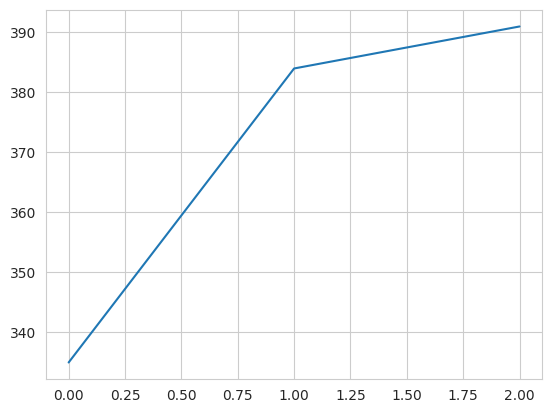

In [ ]:
plt.plot(urdu_doc['Label'].value_counts())

In [ ]:
urdu_doc['Label'].value_counts()

2    391
1    384
0    335
Name: Label, dtype: int64

### Removing stops words

In [ ]:
!pip install urduhack
import urduhack
urduhack.download()

In [ ]:
#Remove unwanted characters, stopwords, and format the text to create fewer nulls word embeddings

def removing_unwanted_data(text):

    # Format words and remove unwanted characters
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)

    # remove stop words
#     if remove_stopwords:
#         text = text.split()
#         stops = set(stopwords.words("english"))
#         text = [w for w in text if not w in stops]
#         text = " ".join(text)

    # Tokenize each word
    text =  nltk.WordPunctTokenizer().tokenize(text)

    return text


In [ ]:
urdu_doc['text_cleaned']= list(map(removing_unwanted_data,urdu_doc.Sentence))

In [ ]:
urdu_doc.head()

,Sentence,Label,text_cleaned
0,السلام علیکم، میں سیون اپ پیاتھا لیکن میرے خیا...,0,"[السلام, علیکم, ،, میں, سیون, اپ, پیاتھا, لیکن..."
1,السلام علیکم، میں لیز کھائےہوں اور میں ضرور کہ...,1,"[السلام, علیکم, ،, میں, لیز, کھائےہوں, اور, می..."
2,السلام علیکم، میں نے یپسی پیاتھا اور میرے خیال...,0,"[السلام, علیکم, ،, میں, نے, یپسی, پیاتھا, اور,..."
3,السلام علیکم، میں نے لیز کھائےہوں اور میرے خیا...,0,"[السلام, علیکم, ،, میں, نے, لیز, کھائےہوں, اور..."
4,السلام علیکم، میں سیون اپ پیاہوں اور میری رائے...,0,"[السلام, علیکم, ،, میں, سیون, اپ, پیاہوں, اور,..."


### Lemmatization

Get lemma of the word from lookup table
   * Args:
       * **text (str):** Urdu tokenized text
       * **lookup_path (str):** path to the lookup json file
   * Returns:
       * list: A list containing tuple of word and its lemma

In [ ]:
import json

from urduhack.config import LEMMA_LOOKUP_TABLE_PATH

_WORD2LEMMA = None


def lemma_lookup(text, lookup_path: str = LEMMA_LOOKUP_TABLE_PATH) -> list:
    tokens = text
    global _WORD2LEMMA
    if _WORD2LEMMA is None:
        with open(lookup_path, "r", encoding="utf-8") as file:
            _WORD2LEMMA = json.load(file)

    return [_WORD2LEMMA[word] if word in _WORD2LEMMA else word for word in tokens]

urdu_doc['Lemmatized'] =list(map(lemma_lookup,urdu_doc.text_cleaned))

In [ ]:
urdu_doc.head()

,Sentence,Label,text_cleaned,Lemmatized
0,السلام علیکم، میں سیون اپ پیاتھا لیکن میرے خیا...,0,"[السلام, علیکم, ،, میں, سیون, اپ, پیاتھا, لیکن...","[السلام, علیکم, ،, میں, سیون, اپ, پیاتھا, لیکن..."
1,السلام علیکم، میں لیز کھائےہوں اور میں ضرور کہ...,1,"[السلام, علیکم, ،, میں, لیز, کھائےہوں, اور, می...","[السلام, علیکم, ،, میں, لیز, کھائےہوں, اور, می..."
2,السلام علیکم، میں نے یپسی پیاتھا اور میرے خیال...,0,"[السلام, علیکم, ،, میں, نے, یپسی, پیاتھا, اور,...","[السلام, علیکم, ،, میں, نے, یپسی, پیاتھا, اور,..."
3,السلام علیکم، میں نے لیز کھائےہوں اور میرے خیا...,0,"[السلام, علیکم, ،, میں, نے, لیز, کھائےہوں, اور...","[السلام, علیکم, ،, میں, نے, لیز, کھائےہوں, اور..."
4,السلام علیکم، میں سیون اپ پیاہوں اور میری رائے...,0,"[السلام, علیکم, ،, میں, سیون, اپ, پیاہوں, اور,...","[السلام, علیکم, ،, میں, سیون, اپ, پیاہوں, اور,..."


# Feature Engineering
Since machine learning models do not accept the raw text as input data, we need to convert “Reviews” into vectors of numbers.<br>
There are different ways of transforming text into numeric vectors.
<br>In this analysis, I’ve applied first Bag of Words, followed by Bag-of-n-Grams, and later I’ve moved to Tf-Idf which is a more complex representation.<br>
I’ve aimed to model two different classification by using these methodologies and compare their performances on Amazon’s dataset.

#### Bag of word (BOW)
**It is called a “bag” of words, because any information about the order or structure of words in the document is discarded. The model is only concerned with whether known words occur in the document, not where in the document.**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

BOW_convert = CountVectorizer(tokenizer=lambda doc: doc, lowercase=False)
x = BOW_convert.fit_transform(urdu_doc['text_cleaned'])

words = BOW_convert.get_feature_names_out()  # Use get_feature_names_out() instead of get_feature_names()
print("The total number of columns are =", len(words))
print('Shape of arrays =', x.toarray().shape)


The total number of columns are = 1209
Shape of arrays = (1110, 1209)


Since bag-of-words representation converts text into a “flat vector of numbers”, it does not remember any original textual sequence and it can destroy the semantic meaning of the text.<br> In other words, it only records how many times each word appears in the text and it does not give any importance to their order. Each word count becomes a dimension for that specific word.

In [ ]:
import sklearn.model_selection

from sklearn.linear_model import LogisticRegression

train,test= sklearn.model_selection.train_test_split(urdu_doc, train_size = 0.8, random_state=42)

print('Training data set shape =',train.shape)

print('Testing data set shape =',test.shape)

Training data set shape = (888, 4)
Testing data set shape = (222, 4)


### BOW Transformation
Converting the training and testing data into BOW array

In [ ]:
BOW_convert = CountVectorizer(tokenizer=lambda doc: doc, lowercase=False)

X_train = BOW_convert.fit_transform(train['Lemmatized'])

X_test=BOW_convert.transform(test['Lemmatized'])

y_train=train['Sentence']
y_test=test['Sentence']
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(888, 935)
(888,)
(222, 935)
(222,)


### Tf-Idf Tranformation

In [ ]:
tfidf_transform = text.TfidfTransformer(norm=None)

X_train_tfidf = tfidf_transform.fit_transform(X_train)


In [ ]:

X_test_tfidf = tfidf_transform.transform(X_test)

## Logistic Regression

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression

score = []
name = []

def logistic_regression(X_tr, y_tr, X_te, y_te, description, class_labels=None):
    model = LogisticRegression().fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Calculate metrics
    cm = confusion_matrix(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='weighted')  # Change 'weighted' based on your preference
    precision = precision_score(y_te, y_pred, average='weighted')  # Change 'weighted' based on your preference
    recall = recall_score(y_te, y_pred, average='weighted')  # Change 'weighted' based on your preference

    # Display confusion matrix
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    if class_labels is not None:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=class_labels, yticklabels=class_labels)
    else:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix - {}".format(description))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Plot F1 Score
    plt.subplot(1, 3, 2)
    sns.barplot(x=['F1 Score'], y=[f1], palette="viridis")
    plt.title("F1 Score - {}".format(description))

    # Plot Precision and Recall
    plt.subplot(1, 3, 3)
    sns.barplot(x=['Precision', 'Recall'], y=[precision, recall], palette="magma")
    plt.title("Precision and Recall - {}".format(description))

    plt.tight_layout()
    plt.show()

    # Update the global lists
    s = model.score(X_te, y_te)
    score.append(s)
    name.append(description)
    print('Testing Score with', description, 'features:', s)

    return s




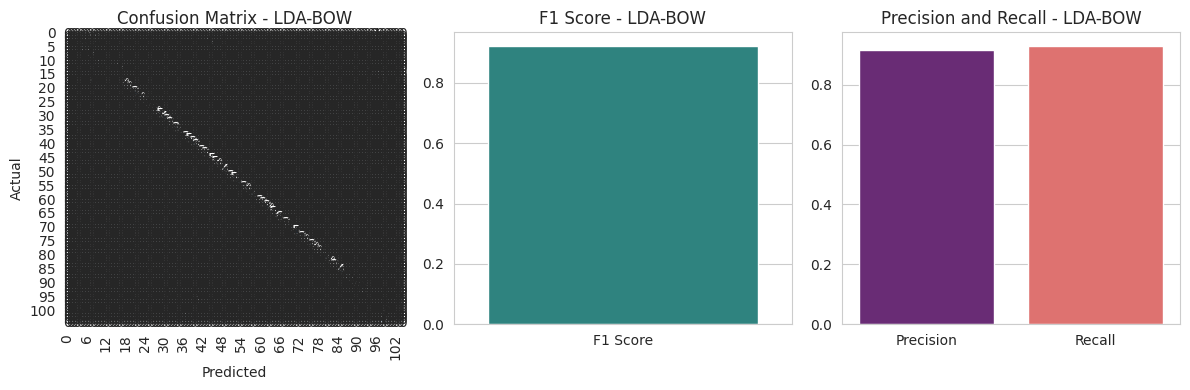

Testing Score with LDA-BOW features: 0.9279279279279279


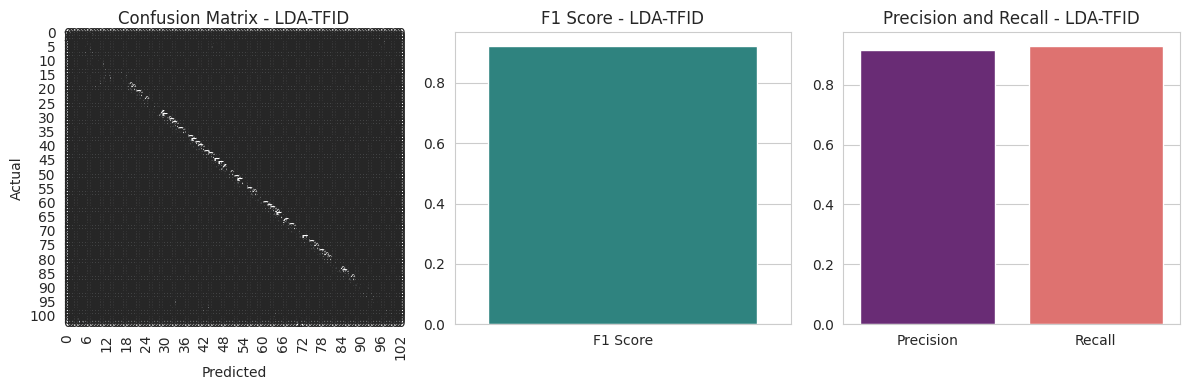

Testing Score with LDA-TFID features: 0.9279279279279279


In [ ]:
accuracy_bow_method=logistic_regression(X_train,y_train,X_test,y_test,"LDA-BOW")
accuracy_tf_if=logistic_regression(X_train_tfidf,y_train,X_test_tfidf,y_test,"LDA-TFID")

## SVM with BOW

In [ ]:
from sklearn import svm
clf = svm.SVC()

clf.fit(X_train, y_train)

ss=clf.score(X_test,y_test)
score.append(ss)
name.append('SVM-BOW')

# get the accuracy
print('Testing Score of SVM with BOW method ', score)


Testing Score of SVM with BOW method  [0.9279279279279279, 0.9279279279279279, 0.2927927927927928]


**Comparing all model  results**

In [ ]:
results=pd.DataFrame()
dictionary=dict()
dictionary['Models']=name
dictionary['Accuracy']=score
results=pd.DataFrame(dictionary )

results

,Models,Accuracy
0,LDA-BOW,0.927928
1,LDA-TFID,0.927928
2,SVM-BOW,0.292793


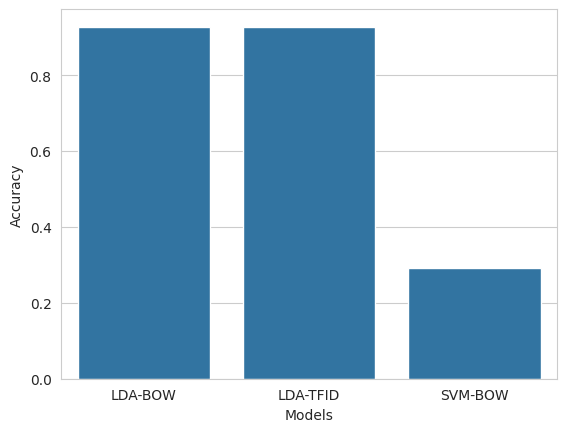

In [ ]:
import seaborn as sns
sns.set_style(style="whitegrid")

ax = sns.barplot(x='Models', y= 'Accuracy',data=results)

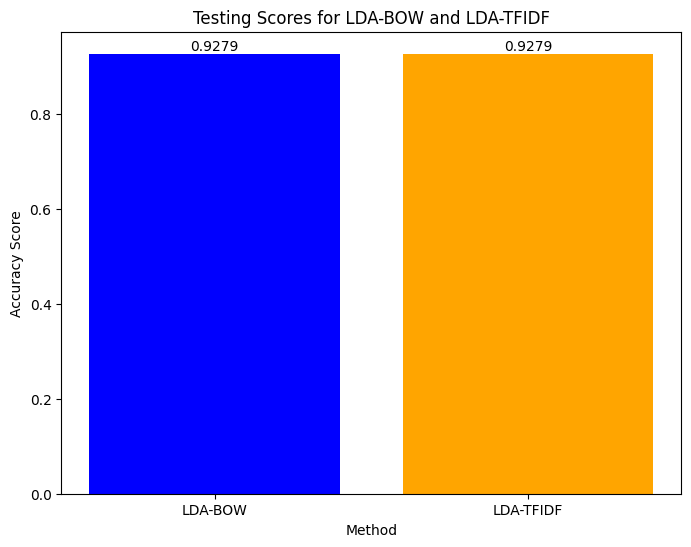

In [1]:
import matplotlib.pyplot as plt

# Testing Scores
scores = [0.927928, 0.927928]

# Set up the bar labels
labels = ['LDA-BOW', 'LDA-TFIDF']

# Creating the bar plot
plt.figure(figsize=(8, 6))
plt.bar(labels, scores, color=['blue', 'orange'])

# Adding the title and labels
plt.title('Testing Scores for LDA-BOW and LDA-TFIDF')
plt.xlabel('Method')
plt.ylabel('Accuracy Score')

# Displaying the score on top of each bar
for i in range(len(scores)):
    plt.text(i, scores[i], f'{scores[i]:.4f}', ha = 'center', va = 'bottom')

# Show the plot
plt.show()


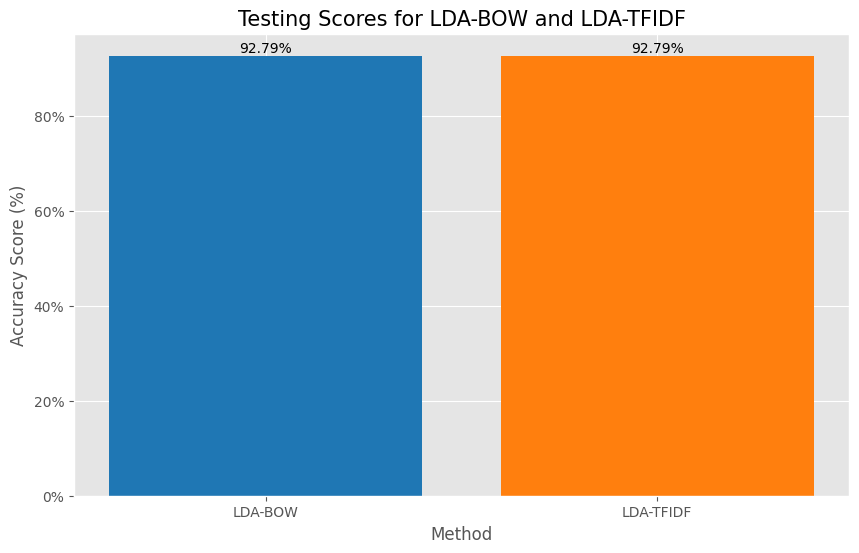

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Testing Scores as percentages
scores = [0.927928, 0.927928]

# Converting scores to percentages and rounding
scores_percentage = [round(score * 100, 2) for score in scores]

# Set up the bar labels
labels = ['LDA-BOW', 'LDA-TFIDF']

# Creating the bar plot with a more professional style
plt.style.use('ggplot')  # Using ggplot style for a more professional look
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, scores_percentage, color=['#1f77b4', '#ff7f0e'])

# Adding the title and labels with font size adjustments
plt.title('Testing Scores for LDA-BOW and LDA-TFIDF', fontsize=15)
plt.xlabel('Method', fontsize=12)
plt.ylabel('Accuracy Score (%)', fontsize=12)

# Formatting the y-axis to display percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

# Displaying the score on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%', ha='center', va='bottom', fontsize=10)

# Show the plot
plt.show()


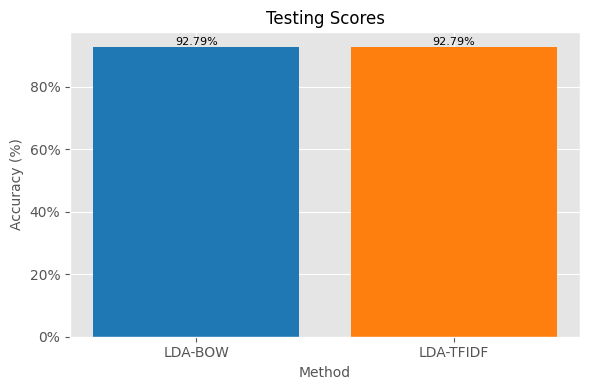

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Testing Scores as percentages
scores = [0.927928, 0.927928]

# Converting scores to percentages and rounding
scores_percentage = [round(score * 100, 2) for score in scores]

# Set up the bar labels
labels = ['LDA-BOW', 'LDA-TFIDF']

# Creating the bar plot with a compact style
plt.style.use('ggplot')  # Using ggplot style
plt.figure(figsize=(6, 4))  # Smaller figure size
bars = plt.bar(labels, scores_percentage, color=['#1f77b4', '#ff7f0e'])

# Adding the title and labels with font size adjustments
plt.title('Testing Scores', fontsize=12)
plt.xlabel('Method', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)

# Formatting the y-axis to display percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

# Displaying the score on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%', ha='center', va='bottom', fontsize=8)

# Adjust layout for a compact view
plt.tight_layout()

# Show the plot
plt.show()


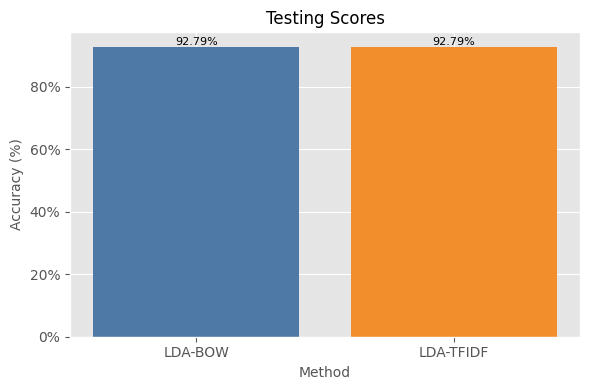

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Testing Scores as percentages
scores = [0.927928, 0.927928]

# Converting scores to percentages and rounding
scores_percentage = [round(score * 100, 2) for score in scores]

# Set up the bar labels
labels = ['LDA-BOW', 'LDA-TFIDF']

# Creating the bar plot with an aesthetically pleasing color scheme
plt.style.use('ggplot')  # Using ggplot style
plt.figure(figsize=(6, 4))  # Compact figure size
colors = ['#4e79a7', '#f28e2b']  # Aesthetic color choices
bars = plt.bar(labels, scores_percentage, color=colors)

# Adding the title and labels with font size adjustments
plt.title('Testing Scores', fontsize=12)
plt.xlabel('Method', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)

# Formatting the y-axis to display percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

# Displaying the score on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%', ha='center', va='bottom', fontsize=8)

# Adjust layout for a compact view
plt.tight_layout()

# Show the plot
plt.show()


-----------------------------------